# Merging MIDL with External Satellite Data: An Example with IMP-8

There are rare times when the MIDL dataset relies on ACE as its sole L1 source. However, users can enhance coverage by merging MIDL data with external sources (IMP-8, Geotail, ISEE, etc.) at a shared spatial position.

This tutorial demonstrates the full workflow:
1. Download IMP-8 data from CDAWeb
2. Parse and process IMP-8 measurements into MIDL-compatible variables
3. Propagate ACE (MIDL L1) to IMP-8's position
4. Merge the two datasets using `midl.merge()`
5. Propagate the merged result to 14 Re

**Date**: 1998-11-15. ACE plasma drops out at ~13:25 UT (44% of the day missing). IMP-8 is at X_GSM ≈ 30–33 Re, close to the Sun–Earth line — ideal for ballistic propagation.

**Prerequisites**: `pip install csem-midl cdflib matplotlib`

In [24]:
import midl
import cdflib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import requests
from pathlib import Path

## 1. Download IMP-8 Data from CDAWeb

IMP-8 data is available as CDF files from NASA's CDAWeb archive. We need:
- **Magnetic field** (`I8_15SEC_MAG`): 15-second cadence, B vector in GSM coordinates
- **Plasma** (`I8_H0_MITPLASMA`): ~2.5 minute cadence, flow speed, angles, density, thermal speed

In [39]:
mag_url = "https://cdaweb.gsfc.nasa.gov/sp_phys/data/imp/imp8/mag/mag_15sec_cdaweb/1998/i8_15sec_mag_19981115_v03.cdf"
pls_url = "https://cdaweb.gsfc.nasa.gov/sp_phys/data/imp/imp8/plasma_mit/mitplasma_h0/1998/i8_h0_mitplasma_19981115_v01.cdf"

for url in [mag_url, pls_url]:
    fname = Path(url).name
    if not Path(fname).exists():
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        Path(fname).write_bytes(r.content)

## 2. Load and Inspect MIDL L1 Data

MIDL L1 data for this era is ACE-only. The `B_source`, `Ux_source`, etc. columns will all show source code `1` (ACE).

In [40]:
ds_midl = midl.load("1998-11-15", "1998-11-16", "l1")
print(ds_midl)

<xarray.Dataset> Size: 173kB
Dimensions:     (time: 1441)
Coordinates:
  * time        (time) datetime64[us] 12kB 1998-11-15 ... 1998-11-16
Data variables: (12/14)
    Bx          (time) float64 12kB -0.4 -0.4 -0.13 -0.03 ... nan nan nan nan
    By          (time) float64 12kB -9.04 -9.0 -8.94 -8.94 ... nan nan nan nan
    Bz          (time) float64 12kB 1.22 1.28 1.9 1.9 -0.85 ... nan nan nan nan
    Ux          (time) float64 12kB -366.1 -366.3 -366.3 -363.6 ... nan nan nan
    Uy          (time) float64 12kB 79.32 85.7 85.7 86.42 ... nan nan nan nan
    Uz          (time) float64 12kB 5.68 7.25 7.25 10.84 ... nan nan nan nan
    ...          ...
    X           (time) float64 12kB 220.1 220.1 220.1 ... 220.1 220.1 220.0
    B_source    (time) float64 12kB 1.0 1.0 1.0 1.0 1.0 ... nan nan nan nan nan
    Ux_source   (time) float64 12kB 1.0 1.0 1.0 1.0 1.0 ... nan nan nan nan nan
    Uyz_source  (time) float64 12kB 1.0 1.0 1.0 1.0 1.0 ... nan nan nan nan nan
    rho_source  (time) floa

### MIDL L1 — ACE data with gap

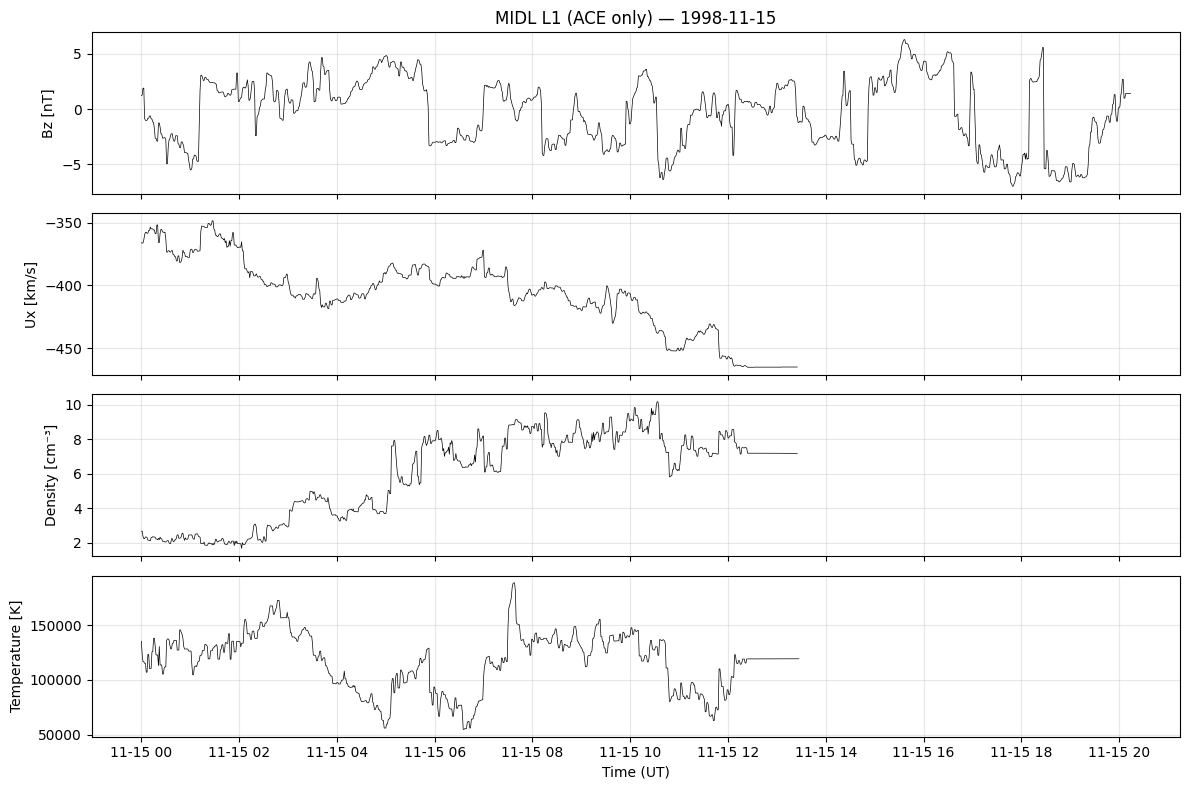

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
t = ds_midl.time.values

for ax, var, label, unit in zip(
    axes,
    ["Bz", "Ux", "rho", "T"],
    ["Bz", "Ux", "Density", "Temperature"],
    ["nT", "km/s", "cm\u207b\u00b3", "K"],
):
    ax.plot(t, ds_midl[var].values, 'k', lw=0.5)
    ax.set_ylabel(f"{label} [{unit}]")
    ax.grid(True, alpha=0.3)

axes[0].set_title("MIDL L1 (ACE only) \u2014 1998-11-15")
axes[-1].set_xlabel("Time (UT)")
plt.tight_layout()
plt.show()

## 3. Parse IMP-8 Data

The mag CDF provides `B_Vector_GSM` directly in GSM coordinates — no rotation needed. We filter to solar-wind-only intervals (`SW_flag == 0`) and resample from 15-second to 1-minute cadence.

The plasma CDF provides flow speed and angles rather than velocity components. We decompose speed + angles into Ux, Uy, Uz and convert thermal speed to temperature ($T = m_p v_{th}^2 / 2 k_B$). The velocity decomposition gives GSE components; since the GSE\u2192GSM rotation is purely around X, Ux is identical in both frames. For Uy/Uz the dipole tilt correction is small, we use GSE as an approximation.

In [41]:
# --- Magnetic field ---
cdf_mag = cdflib.CDF("i8_15sec_mag_19981115_v03.cdf")
epoch_mag = cdf_mag.varget("Epoch")
time_mag = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch_mag))
b_gsm = cdf_mag.varget("B_Vector_GSM").astype(float)
pos_gsm = cdf_mag.varget("SC_Pos_GSM").astype(float)
sw_flag = cdf_mag.varget("SW_flag")

b_gsm[b_gsm > 9000] = np.nan
pos_gsm[pos_gsm > 900] = np.nan

df_mag = pd.DataFrame({
    "Bx": b_gsm[:, 0], "By": b_gsm[:, 1], "Bz": b_gsm[:, 2],
    "X": pos_gsm[:, 0],
}, index=time_mag)
df_mag = df_mag[sw_flag == 0].resample("1min").mean()

# --- Plasma ---
cdf_pls = cdflib.CDF("i8_h0_mitplasma_19981115_v01.cdf")
epoch_pls = cdf_pls.varget("Epoch")
time_pls = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch_pls))
V = cdf_pls.varget("V_fit").astype(float)
ew_angle = cdf_pls.varget("EW_flowangle_best").astype(float)
elevation = cdf_pls.varget("Flow_elevation_threshsp").astype(float)
density = cdf_pls.varget("proton_density_fit").astype(float)
v_th = cdf_pls.varget("protonV_thermal_fit").astype(float)
region = cdf_pls.varget("Region")

for arr in [V, ew_angle, elevation, density, v_th]:
    arr[arr > 9000] = np.nan

ew_rad = np.deg2rad(ew_angle)
elev_rad = np.deg2rad(elevation)
m_p, k_B = 1.6726e-27, 1.3807e-23

df_pls = pd.DataFrame({
    "Ux": -V * np.cos(elev_rad) * np.cos(ew_rad),
    "Uy": -V * np.cos(elev_rad) * np.sin(ew_rad),
    "Uz": -V * np.sin(elev_rad),
    "rho": density,
    "T": m_p * (v_th * 1e3)**2 / (2 * k_B),
}, index=time_pls)
df_pls = df_pls[region == 1].resample("1min").mean()

# --- Combine into xr.Dataset ---
df_imp8 = df_mag[["Bx", "By", "Bz", "X"]].join(df_pls, how="outer")
ds_imp8 = xr.Dataset.from_dataframe(df_imp8.rename_axis("time"))

## 4. Process IMP-8 Data

Before merging, we apply the same pre-processing MIDL uses on each satellite:
1. **Gap interpolation** — fill small gaps per variable (B: 5 min, plasma: 60 min)
2. **3-point median filter** (despike) — remove single-minute instrument artifacts

In [42]:
interp_limits = {'Bx': 5, 'By': 5, 'Bz': 5, 'Ux': 60, 'Uy': 60, 'Uz': 60, 'rho': 60, 'T': 60}

# Gap interpolation
for var, limit in interp_limits.items():
    if var in ds_imp8:
        before = int(ds_imp8[var].isnull().sum())
        ds_imp8[var] = ds_imp8[var].interpolate_na(
            dim='time', method='linear',
            max_gap=pd.Timedelta(minutes=limit),
        )
        after = int(ds_imp8[var].isnull().sum())
        if before - after > 0:
            print(f"  {var}: filled {before - after} gaps ({after} NaN remaining)")

# 3-point median filter (despike)
for var in ['Bx', 'By', 'Bz', 'Ux', 'Uy', 'Uz', 'rho']:
    if var in ds_imp8:
        vals = ds_imp8[var].values.copy()
        filtered = pd.Series(vals).rolling(3, center=True, min_periods=2).median().values
        ds_imp8[var] = xr.DataArray(filtered, dims='time')

  Bx: filled 16 gaps (144 NaN remaining)
  By: filled 16 gaps (144 NaN remaining)
  Bz: filled 16 gaps (144 NaN remaining)
  Ux: filled 427 gaps (406 NaN remaining)
  Uy: filled 427 gaps (406 NaN remaining)
  Uz: filled 427 gaps (406 NaN remaining)
  rho: filled 686 gaps (127 NaN remaining)
  T: filled 686 gaps (127 NaN remaining)


### IMP-8 Data Overview

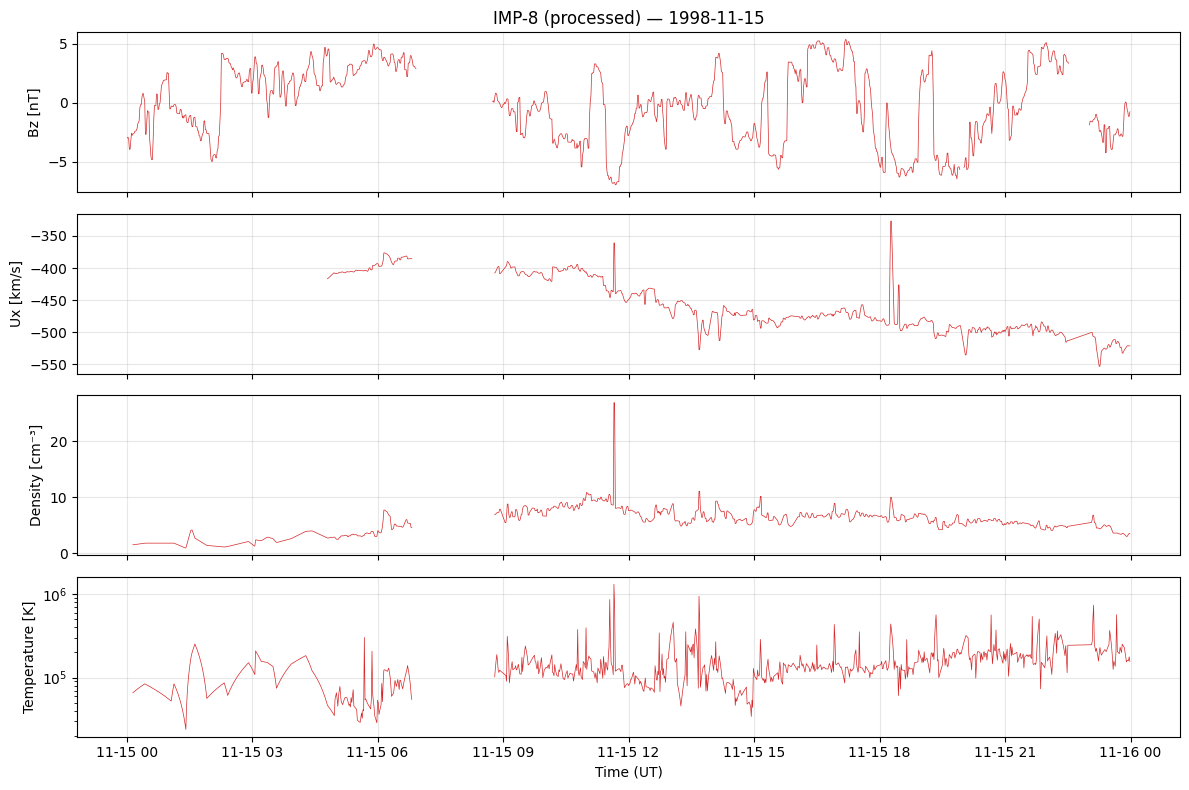

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
t_imp8 = ds_imp8.time.values

for ax, var, label, unit in zip(
    axes,
    ["Bz", "Ux", "rho", "T"],
    ["Bz", "Ux", "Density", "Temperature"],
    ["nT", "km/s", "cm\u207b\u00b3", "K"],
):
    ax.plot(t_imp8, ds_imp8[var].values, 'tab:red', lw=0.5)
    ax.set_ylabel(f"{label} [{unit}]")
    ax.grid(True, alpha=0.3)

axes[3].set_yscale('log')
axes[0].set_title("IMP-8 (processed) \u2014 1998-11-15")
axes[-1].set_xlabel("Time (UT)")
plt.tight_layout()
plt.show()

## 5. Propagate MIDL L1 to IMP-8's Position

IMP-8's X position varies over the day as it orbits. We use the median X_GSM as the merge position, then ballistically propagate the MIDL L1 data from ACE's position (~230 Re) to IMP-8's (~31 Re).

In [31]:
imp8_x_re = float(ds_imp8["X"].median())
print(f"Merge position: {imp8_x_re:.1f} Re")

ds_midl_at_imp8 = midl.propagate(ds_midl, "ballistic", imp8_x_re)
print(f"MIDL propagated to {imp8_x_re:.1f} Re: {len(ds_midl_at_imp8.time)} minutes")

Merge position: 32.3 Re
MIDL propagated to 32.3 Re: 1441 minutes


### ACE (propagated) vs IMP-8 at Merge Position

Overlaying both datasets at the same spatial location. In the morning, both sources have data and should show good agreement. In the afternoon, ACE drops out and only IMP-8 remains.

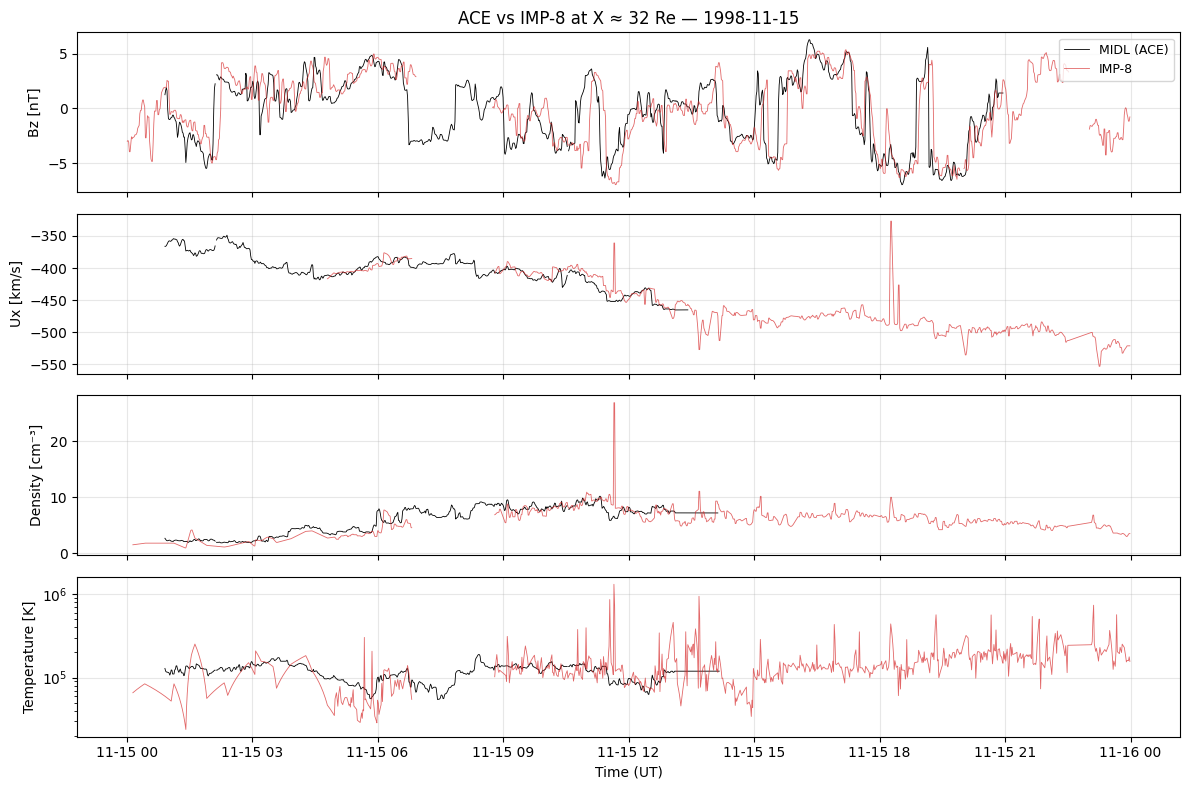

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, var, label, unit in zip(
    axes,
    ["Bz", "Ux", "rho", "T"],
    ["Bz", "Ux", "Density", "Temperature"],
    ["nT", "km/s", "cm\u207b\u00b3", "K"],
):
    ax.plot(ds_midl_at_imp8.time.values, ds_midl_at_imp8[var].values,
            'k', lw=0.6, label='MIDL (ACE)')
    ax.plot(ds_imp8.time.values, ds_imp8[var].values,
            'tab:red', lw=0.6, alpha=0.7, label='IMP-8')
    ax.set_ylabel(f"{label} [{unit}]")
    ax.grid(True, alpha=0.3)

axes[3].set_yscale('log')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title(f"ACE vs IMP-8 at X \u2248 {imp8_x_re:.0f} Re \u2014 1998-11-15")
axes[-1].set_xlabel("Time (UT)")
plt.tight_layout()
plt.show()

## 6. Merge the Datasets

`midl.merge()` uses the same agreement-first source selection as the MIDL pipeline:
- When both sources agree within thresholds --> average/median
- When they disagree --> continuity-based fallback with hysteresis
- When only one source has data --> use that source

The output includes provenance columns showing which source contributed each minute.

In [33]:
ds_merged = midl.merge({"ace": ds_midl_at_imp8, "imp8": ds_imp8})
print(ds_merged)
print(f"\nUx NaN fraction: {float(ds_merged['Ux'].isnull().mean()):.0%} (was 44% with ACE alone)")

<xarray.Dataset> Size: 161kB
Dimensions:     (time: 1441)
Coordinates:
  * time        (time) datetime64[us] 12kB 1998-11-15 ... 1998-11-16
Data variables: (12/13)
    Bx          (time) float64 12kB nan -1.599 -1.705 -1.605 ... 4.992 5.061 nan
    By          (time) float64 12kB nan -9.296 -9.303 -9.303 ... 2.023 2.225 nan
    Bz          (time) float64 12kB nan -3.0 -2.925 -3.075 ... -1.16 -0.7717 nan
    Ux          (time) float64 12kB nan nan nan nan ... -521.2 -521.3 -521.1 nan
    Uy          (time) float64 12kB nan nan nan nan ... 28.23 24.58 26.39 nan
    Uz          (time) float64 12kB nan nan nan nan ... -16.4 -16.4 -13.24 nan
    ...          ...
    T           (time) float64 12kB nan nan nan nan ... 1.6e+05 1.631e+05 nan
    B_source    (time) object 12kB '' 'imp8' 'imp8' 'imp8' ... 'imp8' 'imp8' ''
    Ux_source   (time) object 12kB '' '' '' '' '' ... 'imp8' 'imp8' 'imp8' ''
    Uyz_source  (time) object 12kB '' '' '' '' '' ... 'imp8' 'imp8' 'imp8' ''
    rho_source  (tim

### Merged Result with Source Provenance

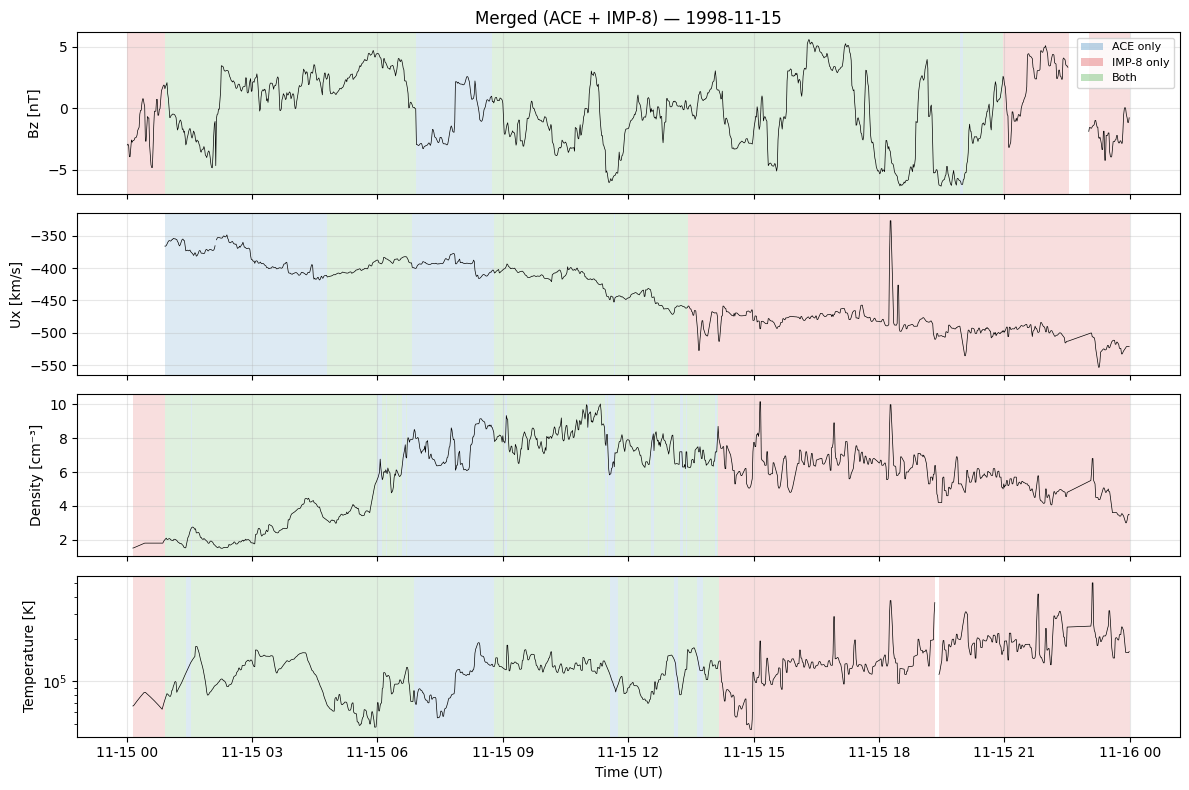

In [34]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
t_merged = ds_merged.time.values
colors = {'ace': 'tab:blue', 'imp8': 'tab:red', 'ace,imp8': 'tab:green', '': 'none'}

source_cols = ["B_source", "Ux_source", "rho_source", "T_source"]

for ax, var, label, unit, src_col in zip(
    axes,
    ["Bz", "Ux", "rho", "T"],
    ["Bz", "Ux", "Density", "Temperature"],
    ["nT", "km/s", "cm\u207b\u00b3", "K"],
    source_cols,
):
    src_vals = ds_merged[src_col].values
    for i in range(len(t_merged) - 1):
        c = colors.get(str(src_vals[i]), 'none')
        if c != 'none':
            ax.axvspan(t_merged[i], t_merged[i + 1], alpha=0.15, color=c, lw=0)
    ax.plot(t_merged, ds_merged[var].values, 'k', lw=0.5)
    ax.set_ylabel(f"{label} [{unit}]")
    ax.grid(True, alpha=0.3)

axes[3].set_yscale('log')

legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.3, label='ACE only'),
    Patch(facecolor='tab:red', alpha=0.3, label='IMP-8 only'),
    Patch(facecolor='tab:green', alpha=0.3, label='Both'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8)
axes[0].set_title("Merged (ACE + IMP-8) \u2014 1998-11-15")
axes[-1].set_xlabel("Time (UT)")
plt.tight_layout()
plt.show()

## 7. Propagate Merged Result to 14 Re

The merged data is at IMP-8's position (~31 Re). We propagate it inward to 14 Re using ballistic propagation, then compare against the standard MIDL 14 Re product (ACE-only).

In [35]:
ds_for_prop = ds_merged.copy()
ds_for_prop["X"] = xr.DataArray(
    np.full(len(ds_for_prop.time), imp8_x_re),
    dims="time",
)

ds_merged_14 = midl.propagate(ds_for_prop, "ballistic", 14)

ds_midl_14 = midl.load("1998-11-15", "1998-11-16", 14)

print(f"Merged at 14 Re: Ux NaN = {float(ds_merged_14['Ux'].isnull().mean()):.0%}")
print(f"MIDL-only at 14 Re: Ux NaN = {float(ds_midl_14['Ux'].isnull().mean()):.0%}")

Merged at 14 Re: Ux NaN = 4%
MIDL-only at 14 Re: Ux NaN = 40%


### MIDL-only vs Merged at 14 Re

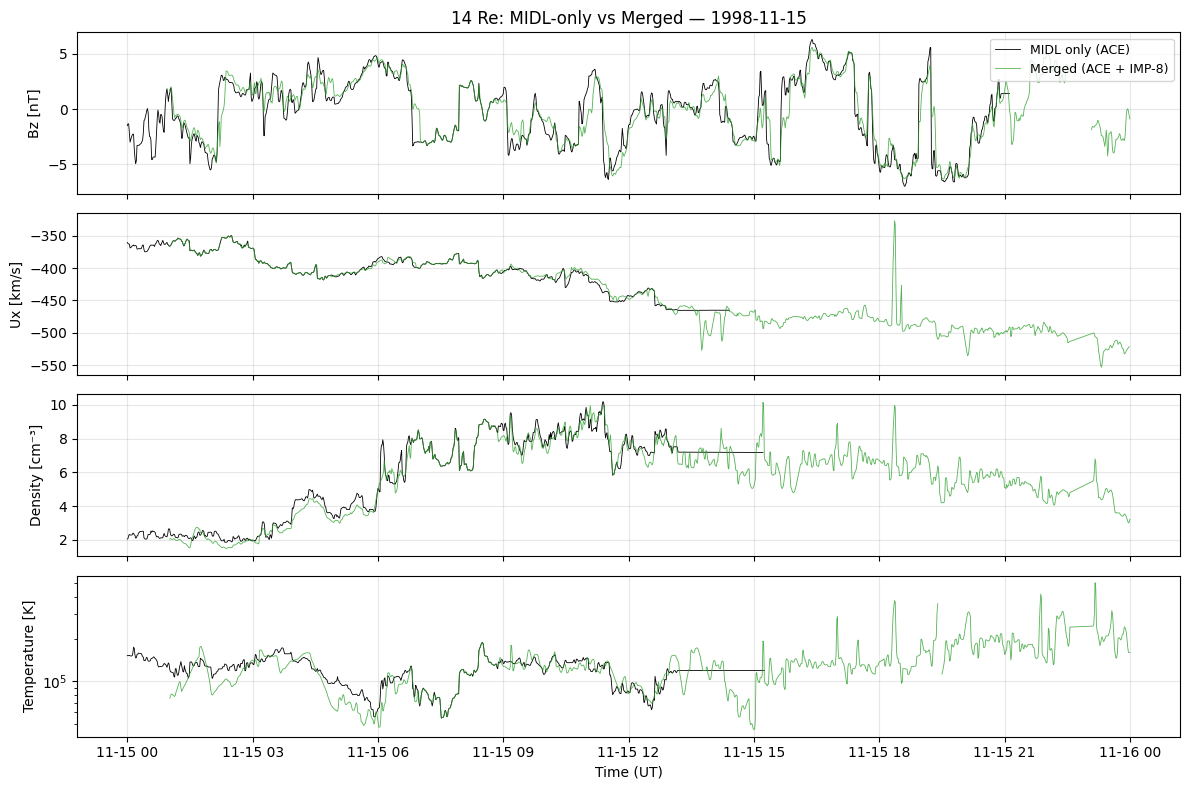

In [36]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, var, label, unit in zip(
    axes,
    ["Bz", "Ux", "rho", "T"],
    ["Bz", "Ux", "Density", "Temperature"],
    ["nT", "km/s", "cm\u207b\u00b3", "K"],
):
    ax.plot(ds_midl_14.time.values, ds_midl_14[var].values,
            'k', lw=0.6, label='MIDL only (ACE)')
    ax.plot(ds_merged_14.time.values, ds_merged_14[var].values,
            'tab:green', lw=0.6, alpha=0.8, label='Merged (ACE + IMP-8)')
    ax.set_ylabel(f"{label} [{unit}]")
    ax.grid(True, alpha=0.3)

axes[3].set_yscale('log')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title("14 Re: MIDL-only vs Merged \u2014 1998-11-15")
axes[-1].set_xlabel("Time (UT)")
plt.tight_layout()
plt.show()

## 8. Save Your Result

In [37]:
midl.to_dat(ds_merged_14, "merged_14Re_19981115.dat")
print("Saved merged_14Re_19981115.dat")

Saved merged_14Re_19981115.dat


## Summary

We merged MIDL L1 (ACE-only) with IMP-8 data on 1998-11-15 to fill ACE's afternoon plasma gap. The workflow:

1. Downloaded IMP-8 mag and plasma CDFs from CDAWeb
2. Derived velocity components from speed + flow angles, temperature from thermal speed
3. Gap-filled and despiked the IMP-8 data (same processing as the MIDL pipeline)
4. Propagated ACE from L1 to IMP-8's position (~31 Re) using `midl.propagate()`
5. Merged the two datasets using `midl.merge()` -> same agreement-first algorithm as the MIDL pipeline
6. Propagated the merged result to 14 Re

This approach works with **any** external solar wind dataset (Geotail, ISEE, etc.); just build an xarray Dataset with the standard variable names (Bx, By, Bz, Ux, Uy, Uz, rho, T) and merge.